In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#shuffling the keras for randomness
keras.utils.set_random_seed(42)  #1    the new things learned will be mentioned like this

In [3]:
df=pd.read_csv("https://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
df.shape

(303, 14)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [6]:
#checking the percentage for each class to find the base line for the model
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


So the baseline for this model is 72 which means the accuracy of our model will have to be more than 72


**Preprocessing**

In [7]:
categorical_variables=["sex","cp","fbs","restecg","exang","ca","thal"]  #these variables will be one hot encoded becaus a NN only accept numeric value
numerics=["age","trestbps","chol","thalach","oldpeak","slope"]         #these variables will be standarized

In [8]:
df=pd.get_dummies(df,columns=categorical_variables)  #2   One-Hot encoding
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [9]:
df.shape

(303, 30)

In [10]:
test_df=df.sample(frac=0.2,random_state=42)  #3  Splitting
train_df=df.drop(test_df.index)

In [11]:
train_df.shape

(242, 30)

In [12]:
test_df.shape

(61, 30)

In [13]:
means=train_df[numerics].mean() #4   For standarization of the numeric variables
sd=train_df[numerics].std()

In [14]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [ ]:
train_df[numerics]=(train_df[numerics]-means)/sd  #5 standarization of numeric variables
test_df[numerics]=(test_df[numerics]-means)/sd

In [15]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [ ]:
#converting the train and test data into numpy arrays
train=train_df.to_numpy()
test=test_df.to_numpy()

In [ ]:
#6 separating the dependent and independent variables
train_X=np.delete(train,6,axis=1).astype(np.float32)
test_X=np.delete(test,6,axis=1).astype(np.float32)


In [ ]:
train_X.shape

(242, 29)

In [ ]:
train_Y=train[:, 6].astype(np.float32)
test_Y=test[:, 6].astype(np.float32)

In [ ]:
train_Y.shape

(242,)

**Build the Model**

In [ ]:
num_columns=train_X.shape[1]

#the input layer
input=keras.Input(shape=(num_columns,))

#the hidden layer
h=keras.layers.Dense(16, activation="relu",name="Hidden")(input)

#output layer
output=keras.layers.Dense(1, activation="sigmoid",name="Output")(h)

#model
model=keras.Model(input,output)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
(29+1)*16+(16+1)*1

497

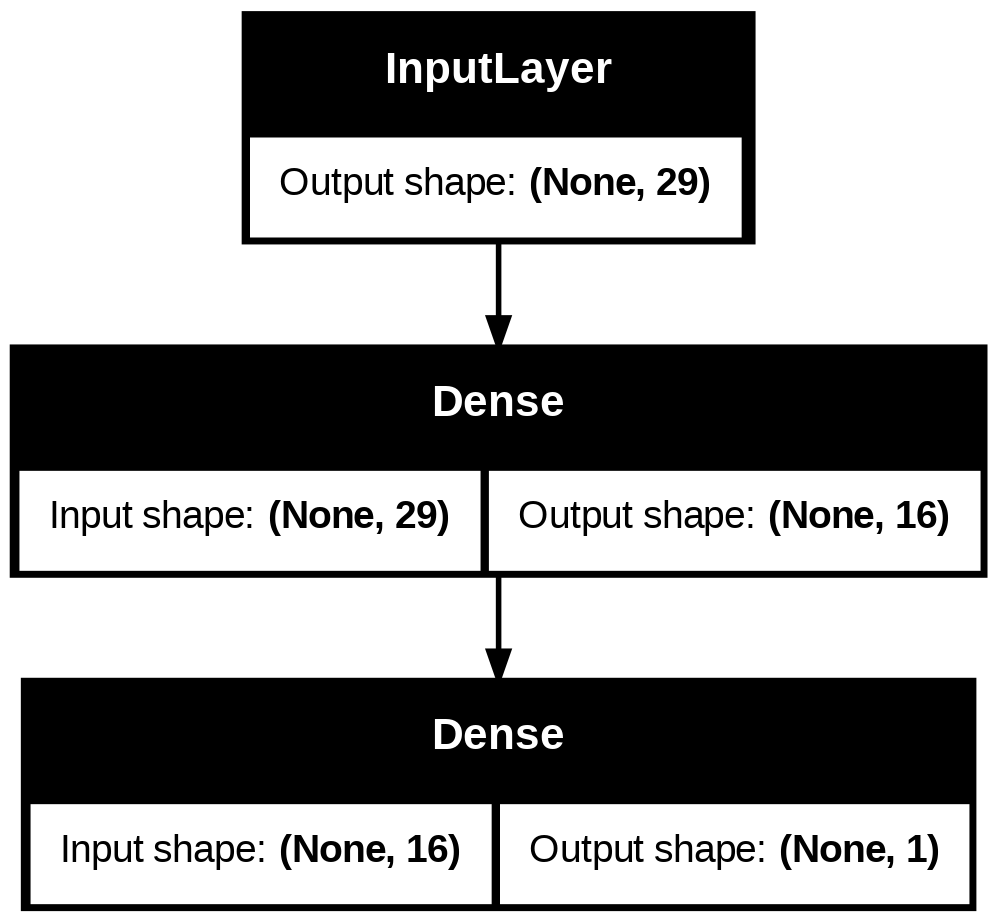

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
history=model.fit(train_X,                #independent
                  train_Y,                #dependent
                  epochs=300,
                  batch_size=32,
                  verbose=1,
                  validation_split=0.2)        #20% of the training data for validation

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5279 - loss: 0.6857 - val_accuracy: 0.5102 - val_loss: 0.6929
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6391 - loss: 0.6396 - val_accuracy: 0.5714 - val_loss: 0.6654
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7259 - loss: 0.6037 - val_accuracy: 0.6531 - val_loss: 0.6421
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7730 - loss: 0.5720 - val_accuracy: 0.6531 - val_loss: 0.6216
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7968 - loss: 0.5435 - val_accuracy: 0.6531 - val_loss: 0.6038
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7966 - loss: 0.5179 - val_accuracy: 0.6735 - val_loss: 0.5878
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8005 - loss: 0.4948 - val_accuracy: 0.6939 - val_loss: 0.5732
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8055 - loss: 0.4741 - val_accuracy: 0.7143 - val_loss:

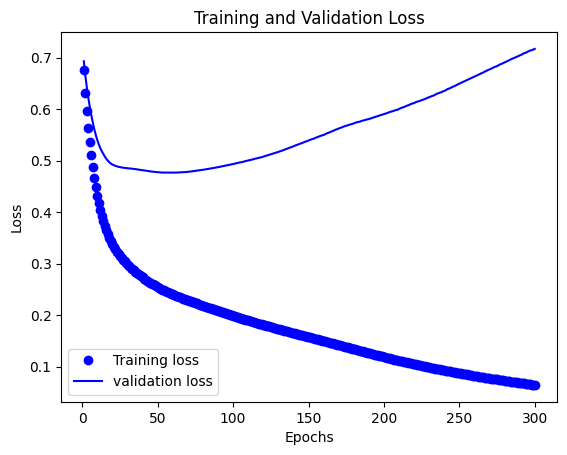

In [ ]:
history_dict=history.history
history_dict.keys()
loss_values=history_dict['loss']
val_loss_values=history_dict['val_loss']
epochs=range(1,len(loss_values)+1)
plt.plot(epochs, loss_values,"bo",label="Training loss")
plt.plot(epochs, val_loss_values,"b",label="validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

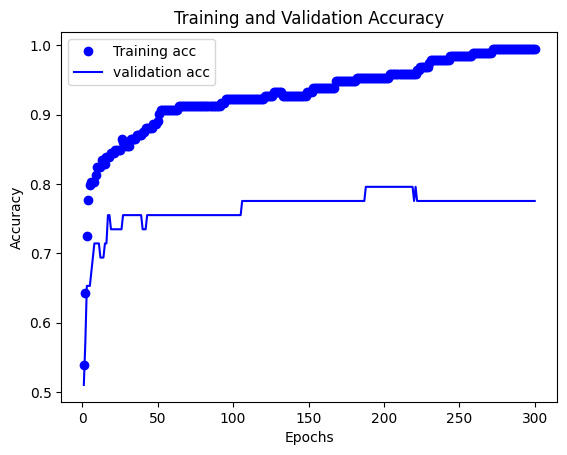

In [ ]:
plt.clf()
acc=history_dict["accuracy"]
val_acc=history_dict["val_accuracy"]
plt.plot(epochs, acc,"bo",label="Training acc")
plt.plot(epochs, val_acc,"b",label="validation acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
p=model.predict(test_X)
p

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[1.6768584e-01],
       [8.6964780e-01],
       [8.9146317e-07],
       [5.1235412e-03],
       [2.0820277e-02],
       [9.9490190e-01],
       [2.4445589e-01],
       [4.8469423e-07],
       [1.2584515e-02],
       [2.8541023e-02],
       [1.6590742e-05],
       [9.8113716e-01],
       [1.1464714e-02],
       [5.0707018e-01],
       [9.6114588e-01],
       [9.7881479e-04],
       [9.1253430e-01],
       [1.3773255e-01],
       [8.2451996e-05],
       [6.9856429e-03],
       [9.9439663e-01],
       [5.3055417e-02],
       [2.9432875e-01],
       [1.5946057e-06],
       [2.1253079e-04],
       [9.5816070e-01],
       [5.1503185e-02],
       [1.6247984e-02],
       [9.9776971e-01],
       [4.7185918e-04],
       [9.9784553e-01],
       [1.2310590e-02],
       [8.5482627e-01],
       [8.1595820e-01],
       [1.5403910e-03],
       [1.5875090e-06],
       [5.0240457e-01],
       [9.1139516e-03],
       [9.0245950e-01],
       [2.3736073e-05],
       [1.9859631e-01],
       [1.408886

In [ ]:
model.evaluate(test_X, test_Y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8277 - loss: 0.5305


[0.5380478501319885, 0.8196721076965332]